In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep
import sys
from sklearn.decomposition import PCA
from typing import List, Optional
import timeit
import awkward as ak
import torch
import torch.nn as nn
from torch.nn import Parameter 
from torch.nn.init import xavier_uniform_, xavier_normal_, constant_
import torch
from torch import nn, Tensor
from typing import Optional
import torch.nn.functional as F
from typing import Optional, Tuple
_is_fastpath_enabled: bool = True
from torch.overrides import (
    handle_torch_function,
    has_torch_function,
    has_torch_function_unary,
    has_torch_function_variadic,
)
linear = torch._C._nn.linear
import math
import random
import warnings
import copy
from torch._C import _add_docstr, _infer_size
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.cm import ScalarMappable

from functools import partial
from weaver.utils.logger import _logger
import os
import uproot
from torch.utils.data import IterableDataset, DataLoader
import numpy as np
from tqdm import tqdm
from torch._torch_docs import reproducibility_notes, sparse_support_notes, tf32_notes


import sys
sys.path.append('../')
import model_utils as mu

In [2]:
interaction_strength = 1.0
model_path = '../models/ParT_full.pt'
model = mu.get_model('jc_full', interaction_strength=interaction_strength)
state_dict = torch.load(model_path, map_location='cpu')
model.load_state_dict(state_dict)

Defaulting to Jet_Class-trained model configuration


<All keys matched successfully>

In [3]:
cls_hooks = mu.ParT_Hook(model, type='class token')
# load small sample of data
n_jets = 5
jc_full_pf_features = np.load('../jc_full_data/jc_full_pf_features.npy')[:n_jets]
jc_kin_pf_features = jc_full_pf_features[:,:7,:]
jc_full_pf_vectors = np.load('../jc_full_data/jc_full_pf_vectors.npy')[:n_jets]
jc_full_pf_mask = np.load('../jc_full_data/jc_full_pf_mask.npy')[:n_jets]
jc_full_pf_points = np.load('../jc_full_data/jc_full_pf_points.npy')[:n_jets]
jc_full_labels = np.load('../jc_full_data/jc_full_labels.npy')[:n_jets]

In [4]:
model.eval()
with torch.no_grad():
    y_pred = model(torch.from_numpy(jc_full_pf_points), torch.from_numpy(jc_full_pf_features), 
                   torch.from_numpy(jc_full_pf_vectors), torch.from_numpy(jc_full_pf_mask))

cls_tokens = cls_hooks.cls_tokens

/home/tim_legge/Interpreting-Particle-Transformers/ablation_study/../model_utils.py:1800: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):
/home/tim_legge/Interpreting-Particle-Transformers/ablation_study/../model_utils.py:576: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


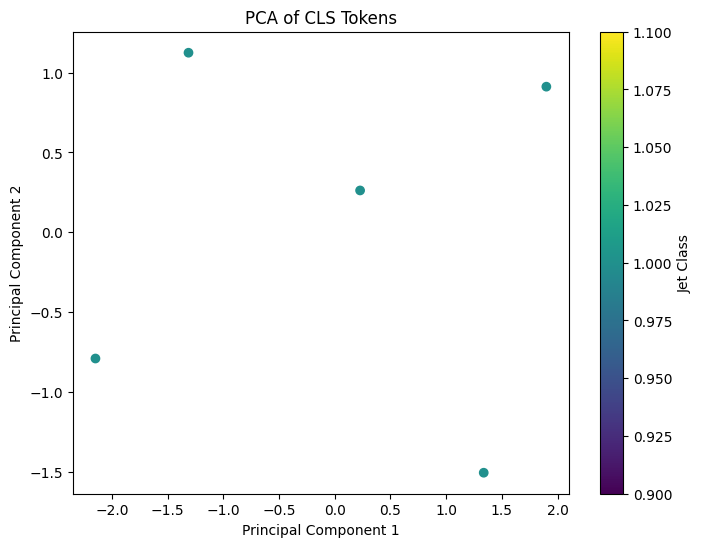

In [8]:
# PCA components on cls tokens
pca = PCA(n_components=2)
cls_tokens_2d = pca.fit_transform(cls_tokens)
plt.figure(figsize=(8,6))
plt.scatter(cls_tokens_2d[:,0], cls_tokens_2d[:,1], c=np.argmax(jc_full_labels,axis=1), cmap='viridis')
plt.colorbar(label='Jet Class')
plt.title('PCA of CLS Tokens')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()